In [1]:
!pip install torch transformers scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
# Load datasets
n = 1
while n < 3:
  from google.colab import files
  uploaded = files.upload()  # Opens a file upload prompt
  n += 1

Saving test_peptide_with_rdkit.csv to test_peptide_with_rdkit.csv


Saving train_peptide_with_rdkit.csv to train_peptide_with_rdkit.csv


In [12]:
import pandas as pd
#train_df = pd.read_csv('/content/train_peptide_with_rdkit.csv').sample(n=70_000)
#test_df  = pd.read_csv('/content/test_peptide_with_rdkit.csv').sample(n=20_000)

import pandas as pd

# Load full datasets
train_df_full = pd.read_csv('/content/train_peptide_with_rdkit.csv')
test_df_full  = pd.read_csv('/content/test_peptide_with_rdkit.csv')

# Sample sizes
train_sample_size = min(70_000, len(train_df_full))
test_sample_size  = min(30_000,  len(test_df_full))

# Statistically sample with random_state for reproducibility
train_df = train_df_full.sample(n=train_sample_size, random_state=42)
test_df  = test_df_full.sample(n=test_sample_size,  random_state=42)

In [13]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.preprocessing import MinMaxScaler

# Inputs
train_smiles   = train_df['smile'].tolist()
train_charges  = train_df['charge'].astype(int).tolist()
test_smiles    = test_df['smile'].tolist()
test_charges   = test_df['charge'].astype(int).tolist()

# Dummy lipid input
lipid_smiles = ['CCO', 'CCC', 'CCN']  # replace with real lipid_df['SMILES']
lipid_charges = [0] * len(lipid_smiles)

# Targets
target_cols = ['ccs', 'mol_weight', 'polar_surface_area', 'h_bond_donors',
               'h_bond_acceptors', 'rotatable_bonds', 'aromatic_rings', 'heavy_atoms']
y_train_orig = train_df[target_cols].values.astype(float)
y_test_orig  = test_df[target_cols].values.astype(float)

# Min-max scaling
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train_orig).astype(np.float32)
y_test  = scaler.transform(y_test_orig).astype(np.float32)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# Dataset
class PeptideDataset(Dataset):
    def __init__(self, smiles, charges, targets, tokenizer, max_len=128):
        self.smiles = smiles
        self.charges = charges
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.smiles)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.smiles[idx],
                             padding='max_length',
                             truncation=True,
                             max_length=self.max_len,
                             return_tensors='pt')
        return {
            'input_ids':     enc['input_ids'].squeeze(0),
            'attention_mask':enc['attention_mask'].squeeze(0),
            'charge':        torch.tensor(self.charges[idx], dtype=torch.long),
            'labels':        torch.tensor(self.targets[idx], dtype=torch.float32)
        }

# Datasets and loaders
train_ds = PeptideDataset(train_smiles,  train_charges, y_train, tokenizer)
test_ds  = PeptideDataset(test_smiles,   test_charges,  y_test,  tokenizer)
lipid_ds = PeptideDataset(lipid_smiles,  lipid_charges, np.zeros((len(lipid_smiles), 8), dtype=np.float32), tokenizer)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
lipid_loader = DataLoader(lipid_ds, batch_size=batch_size, shuffle=False)

In [14]:
import torch
import torch.nn as nn
from transformers import AutoModel

class ChemBERTaWithCharge(nn.Module):
    def __init__(self, n_outputs=8, charge_vocab_size=5):
        super(ChemBERTaWithCharge, self).__init__()
        # Load pre-trained ChemBERTa model
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hidden_size = self.bert.config.hidden_size  # Typically 768

        # Embedding for charge (e.g., 0–4)
        self.charge_emb = nn.Embedding(charge_vocab_size, hidden_size)

        # Linear regressor head for N targets (default: 8)
        self.regressor = nn.Linear(hidden_size, n_outputs)

    def forward(self, input_ids, attention_mask, charge=None, use_charge=True):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token

        if use_charge and charge is not None:
            charge_vec = self.charge_emb(charge)       # (batch_size, hidden_size)
            cls_emb = cls_emb + charge_vec

        out = self.regressor(cls_emb)  # (batch_size, n_outputs)
        return out

# Instantiate model
model = ChemBERTaWithCharge(n_outputs=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Optimizer and loss
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

In [15]:
import torch.nn as nn
import torch
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import pandas as pd
import numpy as np  # ← needed for vstack

# Model definition
class ChemBERTaWithCharge(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.charge_emb = nn.Embedding(5, hs)
        self.regressor  = nn.Linear(hs, 8)  # updated from 4 → 8 targets

    def forward(self, input_ids, attention_mask, charge=None, use_charge=True):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:,0,:]
        if use_charge and charge is not None:
            cls = cls + self.charge_emb(charge)
        return self.regressor(cls)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ChemBERTaWithCharge().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Replace with correct label names used in training
label_names = ['ccs','mol_weight','polar_surface_area','h_bond_donors',
               'h_bond_acceptors','rotatable_bonds','aromatic_rings','heavy_atoms']

def get_preds_and_truth(loader, use_charge):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            chg = b['charge'].to(device) if use_charge else None
            out = model(inp, msk, charge=chg, use_charge=use_charge).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

def get_lipid_preds(loader, use_charge):
    model.eval()
    preds = []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            chg = b['charge'].to(device) if use_charge else None
            out = model(inp, msk, charge=chg, use_charge=use_charge).cpu().numpy()
            preds.append(out)
    return np.vstack(preds)  # now returns only predictions

In [16]:
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import pandas as pd
import numpy as np

# Model
class ChemBERTaWithCharge(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.charge_emb = nn.Embedding(5, hs)
        self.regressor  = nn.Linear(hs, 8)  # 8 targets

    def forward(self, input_ids, attention_mask, charge=None, use_charge=True):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        if use_charge and charge is not None:
            cls = cls + self.charge_emb(charge)
        return self.regressor(cls)

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChemBERTaWithCharge().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# List of regression targets
label_names = ['ccs', 'mol_weight', 'polar_surface_area', 'h_bond_donors',
               'h_bond_acceptors', 'rotatable_bonds', 'aromatic_rings', 'heavy_atoms']

# Helper function for prediction
def get_preds_and_truth(loader, use_charge):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            chg = b['charge'].to(device) if use_charge else None
            out = model(inp, msk, charge=chg, use_charge=use_charge).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

# DataFrames to store metrics
r2_train_df = pd.DataFrame(columns=['epoch', 'loss'] + label_names)
r2_test_df  = pd.DataFrame(columns=['epoch', 'loss'] + label_names)
mae_train_df = pd.DataFrame(columns=['epoch', 'loss'] + label_names)
mae_test_df  = pd.DataFrame(columns=['epoch', 'loss'] + label_names)

# Training loop
num_epochs = 14
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for b in train_loader:
        optimizer.zero_grad()
        out = model(
            b['input_ids'].to(device),
            b['attention_mask'].to(device),
            charge=b['charge'].to(device),
            use_charge=True
        )
        loss = criterion(out, b['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * b['input_ids'].size(0)
    avg_loss = total_loss / len(train_ds)

    # Predictions
    y_tr, yh_tr = get_preds_and_truth(train_loader, use_charge=True)
    y_te, yh_te = get_preds_and_truth(test_loader,  use_charge=True)

    # Inverse transform
    y_tr_inv  = scaler.inverse_transform(y_tr)
    yh_tr_inv = scaler.inverse_transform(yh_tr)
    y_te_inv  = scaler.inverse_transform(y_te)
    yh_te_inv = scaler.inverse_transform(yh_te)

    # Store R² and MAE for each target
    r2_train_row  = {'epoch': epoch, 'loss': avg_loss}
    r2_test_row   = {'epoch': epoch, 'loss': avg_loss}
    mae_train_row = {'epoch': epoch, 'loss': avg_loss}
    mae_test_row  = {'epoch': epoch, 'loss': avg_loss}

    for i, name in enumerate(label_names):
        r2_train_row[name]  = r2_score(y_tr_inv[:, i], yh_tr_inv[:, i])
        r2_test_row[name]   = r2_score(y_te_inv[:, i], yh_te_inv[:, i])
        mae_train_row[name] = mean_absolute_error(y_tr_inv[:, i], yh_tr_inv[:, i])
        mae_test_row[name]  = mean_absolute_error(y_te_inv[:, i], yh_te_inv[:, i])

    r2_train_df.loc[len(r2_train_df)]   = r2_train_row
    r2_test_df.loc[len(r2_test_df)]     = r2_test_row
    mae_train_df.loc[len(mae_train_df)] = mae_train_row
    mae_test_df.loc[len(mae_test_df)]   = mae_test_row

    # Print CCS metrics for quick monitoring
    print(f"\n=== Epoch {epoch}/{num_epochs} (Loss {avg_loss:.4f}) ===")
    print(f"CCS R² Train: {r2_train_row['ccs']:.4f} | Test: {r2_test_row['ccs']:.4f}")
    print(f"CCS MAE Train: {mae_train_row['ccs']:.4f} | Test: {mae_test_row['ccs']:.4f}")

# Save all results
r2_train_df.to_csv('chemberta_ccs_rdkit_rsquare_train.csv', index=False)
r2_test_df.to_csv('chemberta_ccs_rdkit_rsquare_test.csv', index=False)
mae_train_df.to_csv('chemberta_ccs_rdkit_mae_train.csv', index=False)
mae_test_df.to_csv('chemberta_ccs_rdkit_mae_test.csv', index=False)

print("\n✅ Saved all R² and MAE CSV files.")


=== Epoch 1/14 (Loss 0.0197) ===
CCS R² Train: 0.6905 | Test: 0.6889
CCS MAE Train: 50.4092 | Test: 50.2663

=== Epoch 2/14 (Loss 0.0110) ===
CCS R² Train: 0.7081 | Test: 0.7060
CCS MAE Train: 48.2888 | Test: 48.1021

=== Epoch 3/14 (Loss 0.0104) ===
CCS R² Train: 0.7304 | Test: 0.7270
CCS MAE Train: 46.8861 | Test: 46.8732

=== Epoch 4/14 (Loss 0.0101) ===
CCS R² Train: 0.7209 | Test: 0.7163
CCS MAE Train: 45.7924 | Test: 45.7206

=== Epoch 5/14 (Loss 0.0099) ===
CCS R² Train: 0.7206 | Test: 0.7108
CCS MAE Train: 47.9406 | Test: 48.5576

=== Epoch 6/14 (Loss 0.0097) ===
CCS R² Train: 0.7250 | Test: 0.7162
CCS MAE Train: 46.7325 | Test: 47.1373

=== Epoch 7/14 (Loss 0.0096) ===
CCS R² Train: 0.7171 | Test: 0.7001
CCS MAE Train: 45.8625 | Test: 46.7344

=== Epoch 8/14 (Loss 0.0094) ===
CCS R² Train: 0.7343 | Test: 0.7108
CCS MAE Train: 46.6962 | Test: 48.5197

=== Epoch 9/14 (Loss 0.0092) ===
CCS R² Train: 0.7450 | Test: 0.7174
CCS MAE Train: 44.6736 | Test: 46.6463

=== Epoch 10/14 (L

CHemberta without RDKit >>>>>

In [17]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.preprocessing import MinMaxScaler

# Inputs
train_smiles  = train_df['smile'].tolist()
train_charges = train_df['charge'].astype(int).tolist()
test_smiles   = test_df['smile'].tolist()
test_charges  = test_df['charge'].astype(int).tolist()

# Target: Only CCS
target_cols = ['ccs']
y_train_orig = train_df[target_cols].values.astype(float)
y_test_orig  = test_df[target_cols].values.astype(float)

# Min-max scaling
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train_orig).astype(np.float32)
y_test  = scaler.transform(y_test_orig).astype(np.float32)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# Dataset
class PeptideDataset(Dataset):
    def __init__(self, smiles, charges, targets, tokenizer, max_len=128):
        self.smiles = smiles
        self.charges = charges
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.smiles[idx],
                             padding='max_length',
                             truncation=True,
                             max_length=self.max_len,
                             return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'charge':         torch.tensor(self.charges[idx], dtype=torch.long),
            'labels':         torch.tensor(self.targets[idx], dtype=torch.float32)
        }

# Datasets and loaders
train_ds = PeptideDataset(train_smiles, train_charges, y_train, tokenizer)
test_ds  = PeptideDataset(test_smiles,  test_charges,  y_test,  tokenizer)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [19]:
import torch
import torch.nn as nn
from transformers import AutoModel

class ChemBERTaWithCharge(nn.Module):
    def __init__(self, n_outputs=1, charge_vocab_size=5):  # CCS is a single target
        super(ChemBERTaWithCharge, self).__init__()
        # Load pre-trained ChemBERTa model
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hidden_size = self.bert.config.hidden_size  # Typically 768

        # Embedding for charge (e.g., 0–4)
        self.charge_emb = nn.Embedding(charge_vocab_size, hidden_size)

        # Linear regressor head for CCS
        self.regressor = nn.Linear(hidden_size, n_outputs)

    def forward(self, input_ids, attention_mask, charge=None, use_charge=True):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token

        if use_charge and charge is not None:
            charge_vec = self.charge_emb(charge)       # (batch_size, hidden_size)
            cls_emb = cls_emb + charge_vec

        out = self.regressor(cls_emb)  # (batch_size, 1)
        return out

# Instantiate model for CCS only
model = ChemBERTaWithCharge(n_outputs=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Optimizer and loss
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

In [20]:
import torch.nn as nn
import torch
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import numpy as np  # Needed for vstack

# Model definition for CCS-only prediction
class ChemBERTaWithCharge(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.charge_emb = nn.Embedding(5, hs)
        self.regressor  = nn.Linear(hs, 1)  # Output size is 1 for CCS

    def forward(self, input_ids, attention_mask, charge=None, use_charge=True):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # CLS token
        if use_charge and charge is not None:
            cls = cls + self.charge_emb(charge)
        return self.regressor(cls)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ChemBERTaWithCharge().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Evaluation function
def get_preds_and_truth(loader, use_charge):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            chg = b['charge'].to(device) if use_charge else None
            out = model(inp, msk, charge=chg, use_charge=use_charge).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

In [21]:
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import pandas as pd
import numpy as np

# Model for CCS-only prediction
class ChemBERTaWithCharge(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.charge_emb = nn.Embedding(5, hs)
        self.regressor  = nn.Linear(hs, 1)  # Single CCS output

    def forward(self, input_ids, attention_mask, charge=None, use_charge=True):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        if use_charge and charge is not None:
            cls = cls + self.charge_emb(charge)
        return self.regressor(cls)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ChemBERTaWithCharge().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Evaluation function
def get_preds_and_truth(loader, use_charge):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            chg = b['charge'].to(device) if use_charge else None
            out = model(inp, msk, charge=chg, use_charge=use_charge).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

# DataFrames to track per-epoch R² and MAE for CCS
rsq_train_df = pd.DataFrame(columns=['epoch', 'loss', 'ccs'])
rsq_test_df  = pd.DataFrame(columns=['epoch', 'loss', 'ccs'])
mae_train_df = pd.DataFrame(columns=['epoch', 'loss', 'ccs'])
mae_test_df  = pd.DataFrame(columns=['epoch', 'loss', 'ccs'])

# Training loop
num_epochs = 14
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for b in train_loader:
        optimizer.zero_grad()
        out = model(
            b['input_ids'].to(device),
            b['attention_mask'].to(device),
            charge=b['charge'].to(device),
            use_charge=True
        )
        loss = criterion(out, b['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * b['input_ids'].size(0)
    avg_loss = total_loss / len(train_ds)

    # Predictions
    y_tr, yh_tr = get_preds_and_truth(train_loader, use_charge=True)
    y_te, yh_te = get_preds_and_truth(test_loader,  use_charge=True)

    # Inverse scale
    y_tr_inv  = scaler.inverse_transform(y_tr)
    yh_tr_inv = scaler.inverse_transform(yh_tr)
    y_te_inv  = scaler.inverse_transform(y_te)
    yh_te_inv = scaler.inverse_transform(yh_te)

    # Metrics for CCS only
    r2_train = r2_score(y_tr_inv, yh_tr_inv)
    mae_train = mean_absolute_error(y_tr_inv, yh_tr_inv)
    r2_test = r2_score(y_te_inv, yh_te_inv)
    mae_test = mean_absolute_error(y_te_inv, yh_te_inv)

    # Save per-epoch to CSV-compatible format
    rsq_train_df.loc[len(rsq_train_df)] = {'epoch': epoch, 'loss': avg_loss, 'ccs': r2_train}
    rsq_test_df.loc[len(rsq_test_df)]   = {'epoch': epoch, 'loss': avg_loss, 'ccs': r2_test}
    mae_train_df.loc[len(mae_train_df)] = {'epoch': epoch, 'loss': avg_loss, 'ccs': mae_train}
    mae_test_df.loc[len(mae_test_df)]   = {'epoch': epoch, 'loss': avg_loss, 'ccs': mae_test}

    # Print summary
    print(f"\n=== Epoch {epoch}/{num_epochs} (Loss {avg_loss:.4f}) ===")
    print(f"Train: R²={r2_train:.4f} | MAE={mae_train:.4f}")
    print(f"Test : R²={r2_test:.4f}  | MAE={mae_test:.4f}")

# Save all 4 metric files
rsq_train_df.to_csv('chemberta_ccs_rsquare_train_70kdata.csv', index=False)
rsq_test_df.to_csv('chemberta_ccs_rsquare_test_70kdata.csv', index=False)
mae_train_df.to_csv('chemberta_ccs_mae_train_70kdata.csv', index=False)
mae_test_df.to_csv('chemberta_ccs_mae_test_70kdata.csv', index=False)

print("\n✅ Saved CCS-only R² and MAE metrics for train and test.")


=== Epoch 1/14 (Loss 0.0107) ===
Train: R²=0.6312 | MAE=51.8688
Test : R²=0.6300  | MAE=51.4297

=== Epoch 2/14 (Loss 0.0051) ===
Train: R²=0.7281 | MAE=46.9732
Test : R²=0.7260  | MAE=46.8544

=== Epoch 3/14 (Loss 0.0048) ===
Train: R²=0.5465 | MAE=63.1663
Test : R²=0.5407  | MAE=63.4641

=== Epoch 4/14 (Loss 0.0046) ===
Train: R²=0.7185 | MAE=46.3562
Test : R²=0.7128  | MAE=46.4303

=== Epoch 5/14 (Loss 0.0046) ===
Train: R²=0.7252 | MAE=47.1080
Test : R²=0.7185  | MAE=47.3777

=== Epoch 6/14 (Loss 0.0045) ===
Train: R²=0.5099 | MAE=66.0281
Test : R²=0.4968  | MAE=66.7107

=== Epoch 7/14 (Loss 0.0044) ===
Train: R²=0.7159 | MAE=48.5184
Test : R²=0.7043  | MAE=49.3147

=== Epoch 8/14 (Loss 0.0044) ===
Train: R²=0.7465 | MAE=44.9087
Test : R²=0.7327  | MAE=45.7838

=== Epoch 9/14 (Loss 0.0043) ===
Train: R²=0.7322 | MAE=46.7942
Test : R²=0.7127  | MAE=48.1988

=== Epoch 10/14 (Loss 0.0042) ===
Train: R²=0.7465 | MAE=43.7530
Test : R²=0.7215  | MAE=45.5220

=== Epoch 11/14 (Loss 0.0042

In [22]:
# Load datasets
n = 1
while n < 9:
  from google.colab import files
  uploaded = files.upload()  # Opens a file upload prompt
  n += 1

KeyboardInterrupt: 

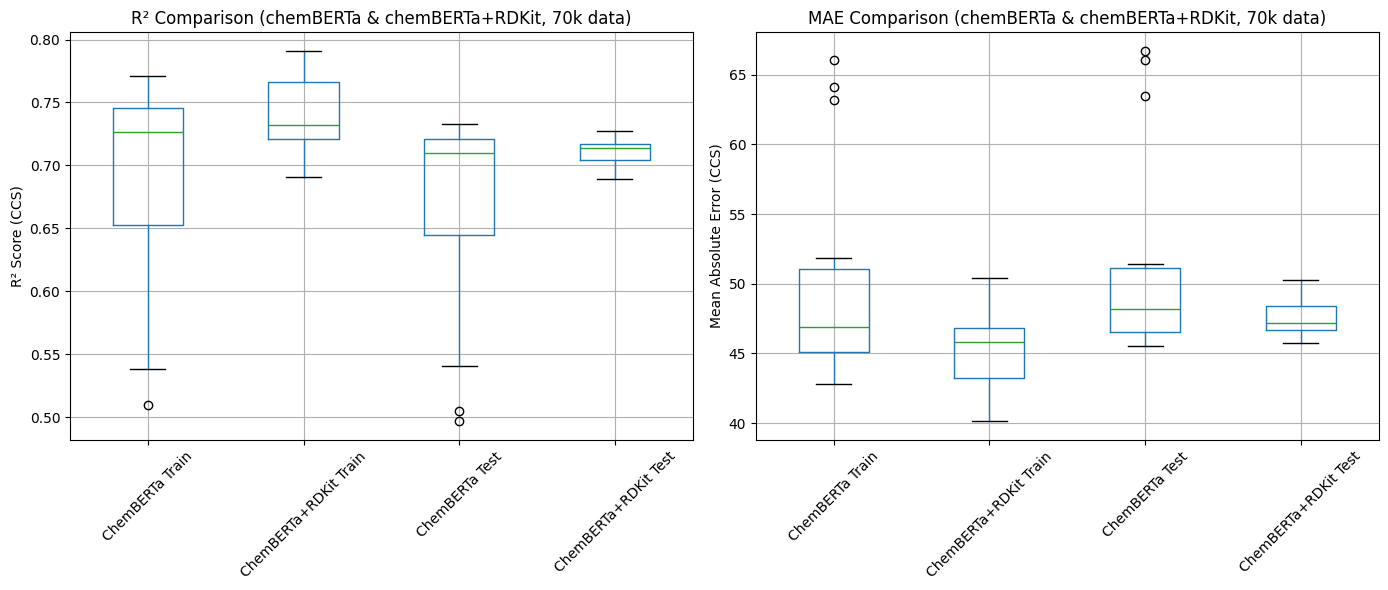

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV files
rsq_train = pd.read_csv('/content/chemberta_ccs_rsquare_train_70k.csv')
rsq_test = pd.read_csv('/content/chemberta_ccs_rsquare_test_70k.csv')
rsq_train_rdkit = pd.read_csv('/content/chemberta_ccs_rdkit_rsquare_train_70k.csv')
rsq_test_rdkit = pd.read_csv('/content/chemberta_ccs_rdkit_rsquare_test_70k.csv')

mae_train = pd.read_csv('/content/chemberta_ccs_mae_train_70k.csv')
mae_test = pd.read_csv('/content/chemberta_ccs_mae_test_70k.csv')
mae_train_rdkit = pd.read_csv('/content/chemberta_ccs_rdkit_mae_train_70k.csv')
mae_test_rdkit = pd.read_csv('/content/chemberta_ccs_rdkit_mae_test_70k.csv')

# Extract only the 'ccs' column
rsquare_data = pd.DataFrame({
    'ChemBERTa Train': rsq_train['ccs'],
    'ChemBERTa+RDKit Train': rsq_train_rdkit['ccs'],
    'ChemBERTa Test': rsq_test['ccs'],
    'ChemBERTa+RDKit Test': rsq_test_rdkit['ccs']
})

mae_data = pd.DataFrame({
    'ChemBERTa Train': mae_train['ccs'],
    'ChemBERTa+RDKit Train': mae_train_rdkit['ccs'],
    'ChemBERTa Test': mae_test['ccs'],
    'ChemBERTa+RDKit Test': mae_test_rdkit['ccs']
})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² subplot
rsquare_data.boxplot(ax=axes[0])
axes[0].set_title('R² Comparison (chemBERTa & chemBERTa+RDKit, 70k data)')
axes[0].set_ylabel('R² Score (CCS)')
axes[0].tick_params(axis='x', rotation=45)

# MAE subplot
mae_data.boxplot(ax=axes[1])
axes[1].set_title('MAE Comparison (chemBERTa & chemBERTa+RDKit, 70k data)')
axes[1].set_ylabel('Mean Absolute Error (CCS)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()